# Replicating Matt's Testing

Goal of this notebook is to replicate the various tests Matt performed with respect to matching B^2, E^2, and BE shifts.

In [2]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def B2_shift(Gx, Gy, Lx, Ly, gamma, B0, V):
    w0 = B0 * gamma
    return gamma**2 / (24 * w0) * (Gx**2 * Lx**2 + Gy**2 * Ly**2) + gamma**2*V**2/(6*w0**3) * (Gx**2 + Gy**2)

def E2_shift(gamma, E, B0, V):
    w0 = B0 * gamma
    return gamma**2*E**2*V**2/(3*299792458.0**4*w0)

def E2_shift_non(gamma, E, B0, Lx, Ly):
    w0 = gamma * B0
    return -gamma**2*E**2/(24*299792458.0**4) * w0 * (Lx**2 + Ly**2)

def BE_shift(gamma, B0, E, Gx, Gy, V):
    w0 = B0 * gamma
    return -gamma**2 * E / (3 * 299792458.0**2 * w0**2) * V**2 * (Gx + Gy)

def analyzeDataset(inpDset, randomSample = False, plot=False):
    errorStates = inpDset[1]['errorState'][-1,:]
    validParticles = np.argwhere(errorStates==0)[:,0]
    times = inpDset[1]['t'][:,0]
    sz = inpDset[1]['s'][:,validParticles,2]
    sy = inpDset[1]['s'][:,validParticles,1]    
    phis = np.arctan2(sz, sy)
    validPhis = np.argwhere(np.logical_not(np.isnan(phis[-1,:])))[:,0]
    phis = phis[:,validPhis]
    for i in range(len(times)):
        if randomSample:
            phis[i,:] = nedmSim.shiftDatapoints(np.random.choice(phis[i,:], size=phis[i,:].shape))
        else:
            phis[i,:] = nedmSim.shiftDatapoints(phis[i,:])
        if plot:
            plt.hist(phis[i,:], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=1)
    means[means > np.pi] -= np.pi*2.0
    means[means < -np.pi] += np.pi*2.0
    stds = np.nanstd(phis, axis=1)
    return times, means, stds, phis.shape[1]

## $E^2$

In [42]:
tf = 100
tout = 10.0
numParticles = 65536
seed = 0

parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='0.01' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='false' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = str(seed) #random number seed for the first particle
parameters['integratorType'] = '2' #the spin integration method
parameters['V'] = '5.0'
parameters['L'] = '1.0, 1.0, 1.0'

Es = np.linspace(0, 250e5, 11)
resultsWithGravity = []
resultsNoGravity = []
for E in Es:
    print(E)
    parameters['E'] = str(E)+', 0.0, 0.0'
    parameters['gravity'] = 'false'
    filename =  'efieldTest.txt'
    outputName = '/storage/home/hcoda1/9/dmathews33/scratch/eSquaredShift.out'
    nedmSim.writeParameterFile(filename, parameters)
    !~/Spin-tracking/bit64main {filename} {outputName}
    resultsNoGravity.append(nedmSim.readInOutputFile(outputName, pad=3))
    
    parameters['gravity'] = 'true'
    filename =  'efieldTest.txt'
    outputName = '/storage/home/hcoda1/9/dmathews33/scratch/eSquaredShift.out'
    nedmSim.writeParameterFile(filename, parameters)
    !~/Spin-tracking/bit64main {filename} {outputName}
    resultsWithGravity.append(nedmSim.readInOutputFile(outputName, pad=3))

0.0
648
iter 0, duration 10, 665
iter 1, duration 20, 628
iter 2, duration 30, 625
iter 3, duration 40, 625
iter 4, duration 50, 625
iter 5, duration 60, 628
iter 6, duration 70, 625
iter 7, duration 80, 626
iter 8, duration 90, 625
iter 9, duration 100, 626
6682
648
iter 0, duration 10, 670
iter 1, duration 20, 658
iter 2, duration 30, 656
iter 3, duration 40, 654
iter 4, duration 50, 651
iter 5, duration 60, 648
iter 6, duration 70, 652
iter 7, duration 80, 651
iter 8, duration 90, 653
iter 9, duration 100, 651
6801
2500000.0
648
iter 0, duration 10, 552
iter 1, duration 20, 545
iter 2, duration 30, 545
iter 3, duration 40, 550
iter 4, duration 50, 545
iter 5, duration 60, 546
iter 6, duration 70, 544
iter 7, duration 80, 544
iter 8, duration 90, 545
iter 9, duration 100, 545
5719
648
iter 0, duration 10, 7954
iter 1, duration 20, 7947
iter 2, duration 30, 7964
iter 3, duration 40, 7978
iter 4, duration 50, 7953
iter 5, duration 60, 7958
iter 6, duration 70, 7969
iter 7, duration 80,

In [43]:
analyzedResultsGravity = []
for res in resultsWithGravity:
    analyzedResultsGravity.append(analyzeDataset(res))

analyzedResultsNoGravity = []
for res in resultsNoGravity:
    analyzedResultsNoGravity.append(analyzeDataset(res))

In [44]:
measuredShiftsGravity = []
errsGrav = []

measuredShiftsNoGravity = []
errsNoGrav = []

calculatedShifts = []
calculatedShiftsNon = []
originalW0 = []
for resGrav, resNoGrav, E, raw in zip(analyzedResultsGravity, analyzedResultsNoGravity, Es, resultsWithGravity):
    expectedShift = E2_shift(raw[0]['gamma'], raw[0]['E'][0], raw[0]['B0'][0], raw[0]['V'])
    w0 = raw[0]['B0'][0] * raw[0]['gamma']
    calculatedShifts.append(expectedShift)
    calculatedShiftsNon.append(E2_shift_non(raw[0]['gamma'], raw[0]['E'][0], raw[0]['B0'][0], raw[0]['L'][0], raw[0]['L'][1]))
    originalW0.append(w0)
    times = raw[1]['t'][:,0]
    calcZ = np.cos(w0*times)
    calcY = np.sin(w0*times)
    calcPhase = np.arctan2(calcZ, calcY)
    measuredShiftsGravity.append((calcPhase- resGrav[1])[-1]/times[-1])
    errsGrav.append(resGrav[2][-1]/times[-1]/np.sqrt(resGrav[3]))
    
    measuredShiftsNoGravity.append((calcPhase- resNoGrav[1])[-1]/times[-1])
    errsNoGrav.append(resNoGrav[2][-1]/times[-1]/np.sqrt(resNoGrav[3]))
    
measuredShiftsGravity = np.array(measuredShiftsGravity)
errsGrav = np.array(errsGrav)

measuredShiftsNoGravity = np.array(measuredShiftsNoGravity)
errsNoGrav = np.array(errsNoGrav)

calculatedShifts = np.array(calculatedShifts)
calculatedShiftsNon = np.array(calculatedShiftsNon)
originalW0 = np.array(originalW0)

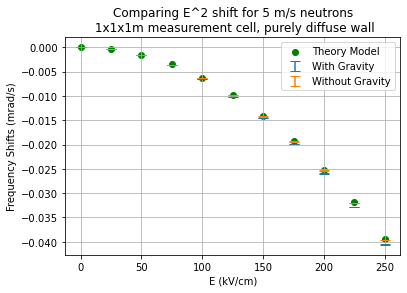

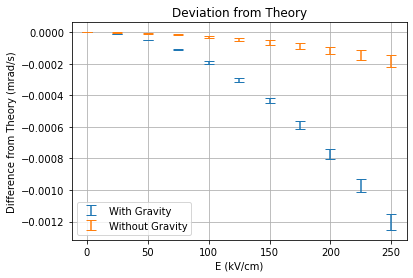

In [45]:
plt.errorbar(Es/100000, measuredShiftsGravity*1000, yerr=errsGrav*1000, linestyle='none', capsize=5, label='With Gravity')
plt.errorbar(Es/100000, measuredShiftsNoGravity*1000, yerr=errsNoGrav*1000, linestyle='none', capsize=5, label='Without Gravity')
plt.scatter(Es/100000, calculatedShifts*1000, label='Theory Model', color='green')
plt.grid()
plt.legend()
plt.xlabel('E (kV/cm)')
plt.ylabel('Frequency Shifts (mrad/s)')
title = 'Comparing E^2 shift for 5 m/s neutrons'
title += '\n 1x1x1m measurement cell, purely diffuse wall'
plt.title(title)

plt.show()

plt.errorbar(Es/100000, measuredShiftsGravity*1000 - calculatedShifts*1000, yerr=errsGrav*1000, capsize = 5, linestyle='none', label='With Gravity')
plt.errorbar(Es/100000, measuredShiftsNoGravity*1000 - calculatedShifts*1000, yerr=errsNoGrav*1000, capsize = 5, linestyle='none', label='Without Gravity')
plt.grid()
plt.legend()
plt.xlabel('E (kV/cm)')
plt.ylabel('Difference from Theory (mrad/s)')
plt.title('Deviation from Theory')
plt.show()